In [7]:
from QiskitTranspiler.transpiler.passes.layout.layout import Layout
from qiskit import QuantumCircuit
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit_aer import AerSimulator
from QiskitTranspiler.transpiler.passes.translation.translator import translate_circuit
from qiskit.converters import circuit_to_dag, dag_to_circuit
from QiskitTranspiler.transpiler.transpile import transpile, apply_layout
from QiskitTranspiler.transpiler.passes.layout.layout import Layout
from QiskitTranspiler.transpiler.passes.translation.translator import translate_circuit
from QiskitTranspiler.transpiler.passes.optimization.optimization import optimize

## Verifying the Correctness of the Transpiler

The `transpile()` function returns a circuit whose size equals the total number of qubits on the targeted hardware, so its fidelity cannot be directly compared to the original circuit. This is addressed in two steps:

1. **Preserve circuit size.** The transpile function is modified to separately return the circuit *before* it is mapped onto the real hardware, keeping it at the same size as the original.

2. **Undo qubit reordering.** After SWAP insertion, qubits in the final circuit are typically reordered relative to the original: for example, qubit 1 might now occupy the position originally held by qubit 2, producing a resulting state of `|011⟩` instead of `|101⟩`. To correctly compute fidelity, these qubits are swapped back to their original positions before comparison.

The cells below implement this procedure and report the resulting fidelity for each test circuit.

In [1]:
def swap_back_for_statevector(qc : QuantumCircuit, mapping):
    """Swap back the qubits in the circuit to their original positions according to the mapping."""
    swapped_qc = qc.copy()
    
    ok = False
    while not ok:
        ok = True
        for should_be, current in mapping.items():
            if should_be != current:
                # find which virtual qubit is currently at the position where should_be is
                other_virtual = next(k for k, v in mapping.items() if v == should_be)
                
                # swap should_be and current in the mapping
                mapping[should_be], mapping[other_virtual] = mapping[other_virtual], mapping[should_be]
                
                # apply the corresponding SWAP to the circuit
                swapped_qc.swap(should_be, current)
                
                ok = False
    print("Final mapping after swaps:", mapping)
    return swapped_qc

In [ ]:
from qiskit.circuit import QuantumCircuit

def transpile_with_mapping(qc, backend):
    """"Modified transpile function that does not map the final circuit to the backend
        and swaps back the qubits to their initial positions."""
    coupling_map = backend.coupling_map
    circuit = qc
    # print(coupling_map)

    INFRASTRUCTURE_GATES = { "measure", "delay", "reset"}
    CONTROL_FLOW_GATES = {"if_else", "for_loop", "switch_case", "while_loop", "break", "continue"}

    basis_gates = [
        g for g in backend.operation_names 
        if g not in INFRASTRUCTURE_GATES and g not in CONTROL_FLOW_GATES
    ]

    layout_no_translate = translate_circuit(qc, basis=basis_gates)
    
    layout_no_translate, mapping = Layout.run_layout(layout_no_translate, backend)
    
    num_qubits = layout_no_translate.num_qubits
    
    # initial_mapping usually maps {Virtual: Physical} - NOT used here
    # We create a working map to track where each virtual qubit ends up
    # Start with an identity mapping: {0: 0, 1: 1, 2: 2, ...}
    # Key = Virtual Qubit Index, Value = Current Physical Position
    current_mapping = {i: i for i in range(num_qubits)}
    
    data = layout_no_translate.data
    i = 0
    while i < len(data):
        inst = data[i]
        
        # 1. Detect explicit SWAP gates
        if inst.operation.name == 'swap':
            q1 = layout_no_translate.find_bit(inst.qubits[0]).index
            q2 = layout_no_translate.find_bit(inst.qubits[1]).index
            _update_position(current_mapping, q1, q2)
            i += 1
            continue

        # 2. Detect CNOT triplets: CX(a,b), CX(b,a), CX(a,b)
        if i + 2 < len(data):
            inst1, inst2, inst3 = data[i], data[i+1], data[i+2]
            
            if (inst1.operation.name == 'cx' and 
                inst2.operation.name == 'cx' and 
                inst3.operation.name == 'cx'):
                
                # Get physical indices
                q1_a = layout_no_translate.find_bit(inst1.qubits[0]).index
                q1_b = layout_no_translate.find_bit(inst1.qubits[1]).index
                
                q2_a = layout_no_translate.find_bit(inst2.qubits[0]).index
                q2_b = layout_no_translate.find_bit(inst2.qubits[1]).index
                
                q3_a = layout_no_translate.find_bit(inst3.qubits[0]).index
                q3_b = layout_no_translate.find_bit(inst3.qubits[1]).index
                
                # Pattern check: CX(a,b), CX(b,a), CX(a,b)
                if (q1_a == q2_b == q3_a) and (q1_b == q2_a == q3_b):
                    _update_position(current_mapping, q1_a, q1_b)
                    i += 3 
                    continue
        
        i += 1
    
    layout_no_translate = swap_back_for_statevector(layout_no_translate, current_mapping)
    

    layout_no_translate = translate_circuit(layout_no_translate, basis=basis_gates)

    layout_no_translate = optimize(layout_no_translate)

    return layout_no_translate, current_mapping

def _update_position(mapping_dict, phys_a, phys_b):
    """
    Swaps the virtual qubits currently residing at physical locations a and b.
    """
    # Find which virtual keys are currently mapped to these physical values
    virt_a = next(k for k, v in mapping_dict.items() if v == phys_a)
    virt_b = next(k for k, v in mapping_dict.items() if v == phys_b)
    
    # Swap their values
    mapping_dict[virt_a], mapping_dict[virt_b] = phys_b, phys_a

## Fidelity Experiments

For the following experiments, the circuits are transpiled for the IBM Fez backend. The statevectors are obtained in each case  for the initial circuit and the transpiled circuit, and are then compared to compute the fidelity.

In [3]:
from qiskit_ibm_runtime.fake_provider import FakeFez, FakeTorino, FakeMarrakesh, FakePerth
from qiskit_ibm_runtime import SamplerV2 as Sampler

backend = FakeFez()

In [8]:
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator
import numpy as np

def get_statevectors(original_qc, routed_qc):
    """
    Get statevectors of original and routed circuits.
    """
    sim = AerSimulator(method='statevector')

    # get statevector of original (no measurements)
    orig_no_meas = original_qc.remove_final_measurements(inplace=False)
    orig_no_meas.save_statevector()
    sv_orig = Statevector(sim.run(orig_no_meas).result().get_statevector())

    # get statevector of routed (no measurements)
    routed_no_meas = QuantumCircuit(routed_qc.num_qubits, routed_qc.num_clbits)
    for instruction in routed_qc.data:
        op = instruction.operation
        qubits = [routed_qc.find_bit(qubit).index for qubit in instruction.qubits]
        cbits = [routed_qc.find_bit(cbit).index for cbit in instruction.clbits]

        if(op.name != "measure"):
            routed_no_meas.append(op, qubits, cbits)
    routed_no_meas.save_statevector()
    sv_routed = Statevector(sim.run(routed_no_meas).result().get_statevector())


    # compare up to global phase
    return sv_orig, sv_routed

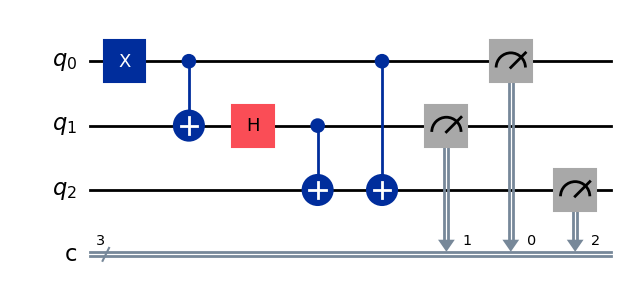

In [9]:
qc = QuantumCircuit(3, 3)
qc.x(0)
qc.cx(0, 1)
qc.h(1)
qc.cx(1, 2)
qc.cx(0, 2)
qc.measure([0, 1, 2], [0, 1, 2])
qc.draw("mpl")

[BasisTranslator] Warning: Found a built-in equivalence table that covers the provided custom_basis. Using 'heron'
Final mapping after swaps: {0: 0, 1: 1, 2: 2}
[BasisTranslator] Warning: Found a built-in equivalence table that covers the provided custom_basis. Using 'heron'


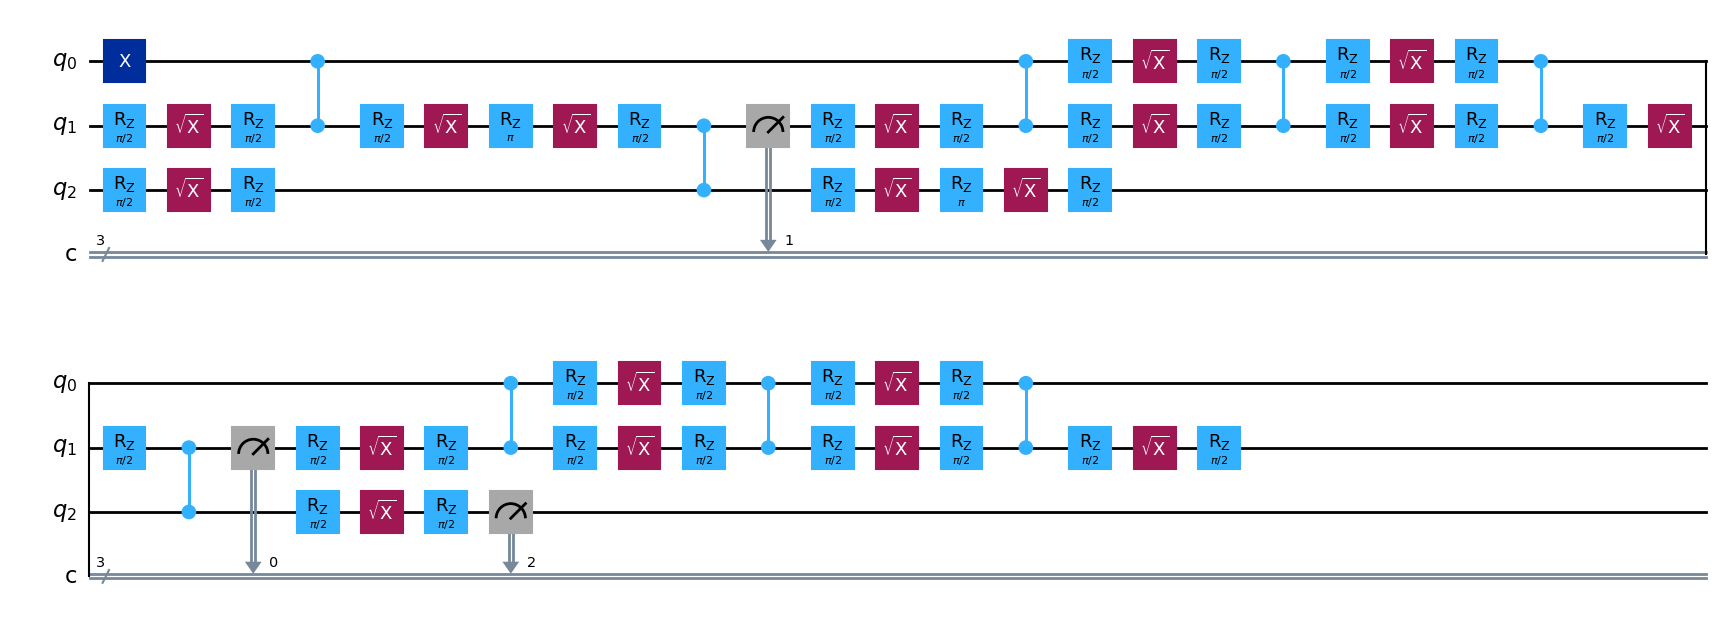

In [10]:
tqc, mapping = transpile_with_mapping(qc, backend)
tqc.draw("mpl")

In [11]:
print("Mapping:", mapping)

Mapping: {0: 0, 1: 1, 2: 2}


In [12]:
sv1, sv2 = get_statevectors(qc, tqc)
sv1.draw("latex")

<IPython.core.display.Latex object>

In [13]:
sv2.draw("latex")

<IPython.core.display.Latex object>

In [14]:
from qiskit.quantum_info import state_fidelity
fidelity = state_fidelity(sv1, sv2)
print("State fidelity:", fidelity)

State fidelity: 1.0000000000000004


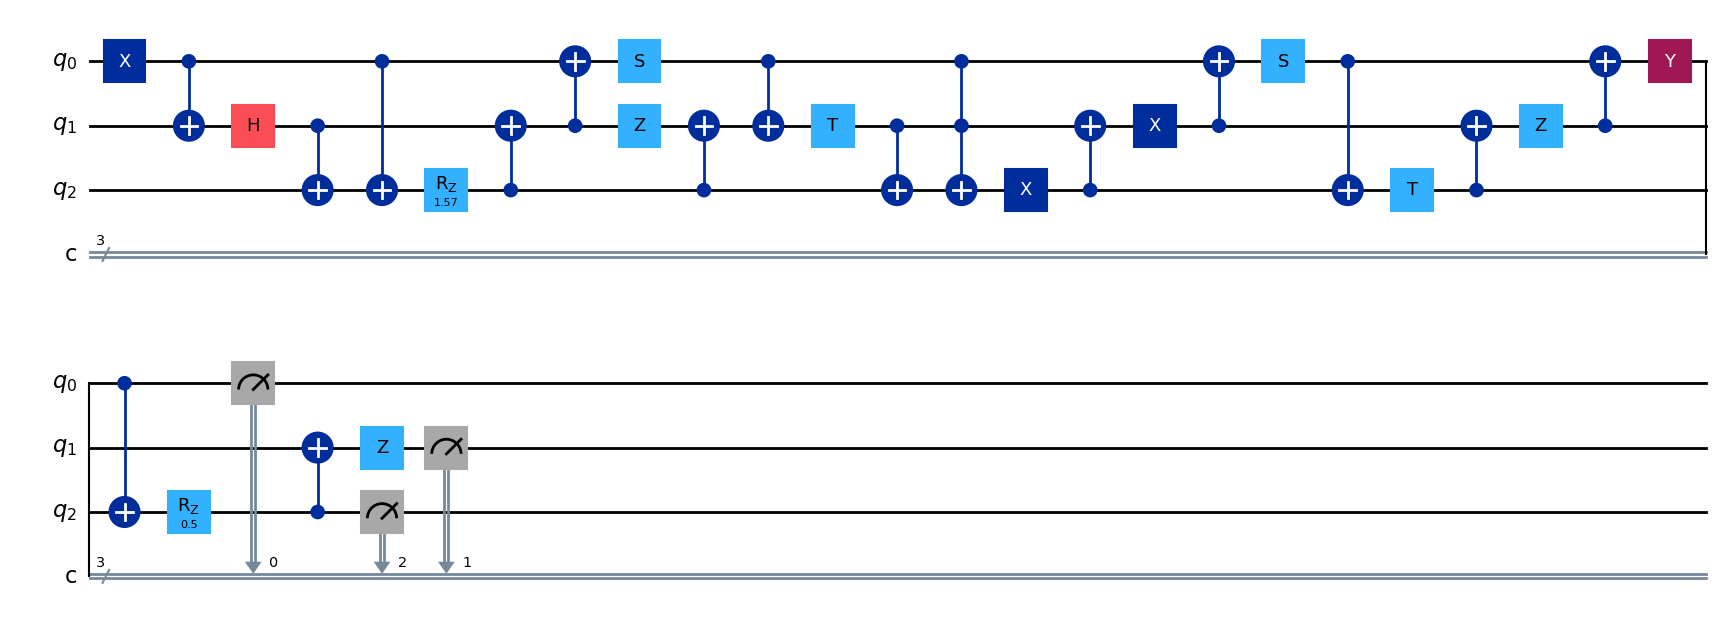

In [15]:
qc = QuantumCircuit(3, 3)

qc.x(0)
qc.cx(0, 1)
qc.h(1)
qc.cx(1, 2)
qc.cx(0, 2)
qc.rz(1.57, 2)
qc.cx(2, 1)
qc.cx(1, 0)
qc.z(1)
qc.cx(2, 1)
qc.s(0)
qc.cx(0, 1)
qc.t(1)
qc.cx(1, 2)
qc.ccx(0, 1, 2)
qc.x(2)
qc.cx(2, 1)
qc.x(1)
qc.cx(1, 0)
qc.s(0)
qc.cx(0, 2)
qc.t(2)
qc.cx(2, 1)
qc.z(1)
qc.cx(1, 0)
qc.y(0)
qc.cx(0, 2)
qc.rz(0.5, 2)
qc.cx(2, 1)
qc.z(1)

qc.measure([0, 1, 2], [0, 1, 2])
qc.draw("mpl")

[BasisTranslator] Warning: Found a built-in equivalence table that covers the provided custom_basis. Using 'heron'
Final mapping after swaps: {0: 0, 1: 1, 2: 2}
[BasisTranslator] Warning: Found a built-in equivalence table that covers the provided custom_basis. Using 'heron'


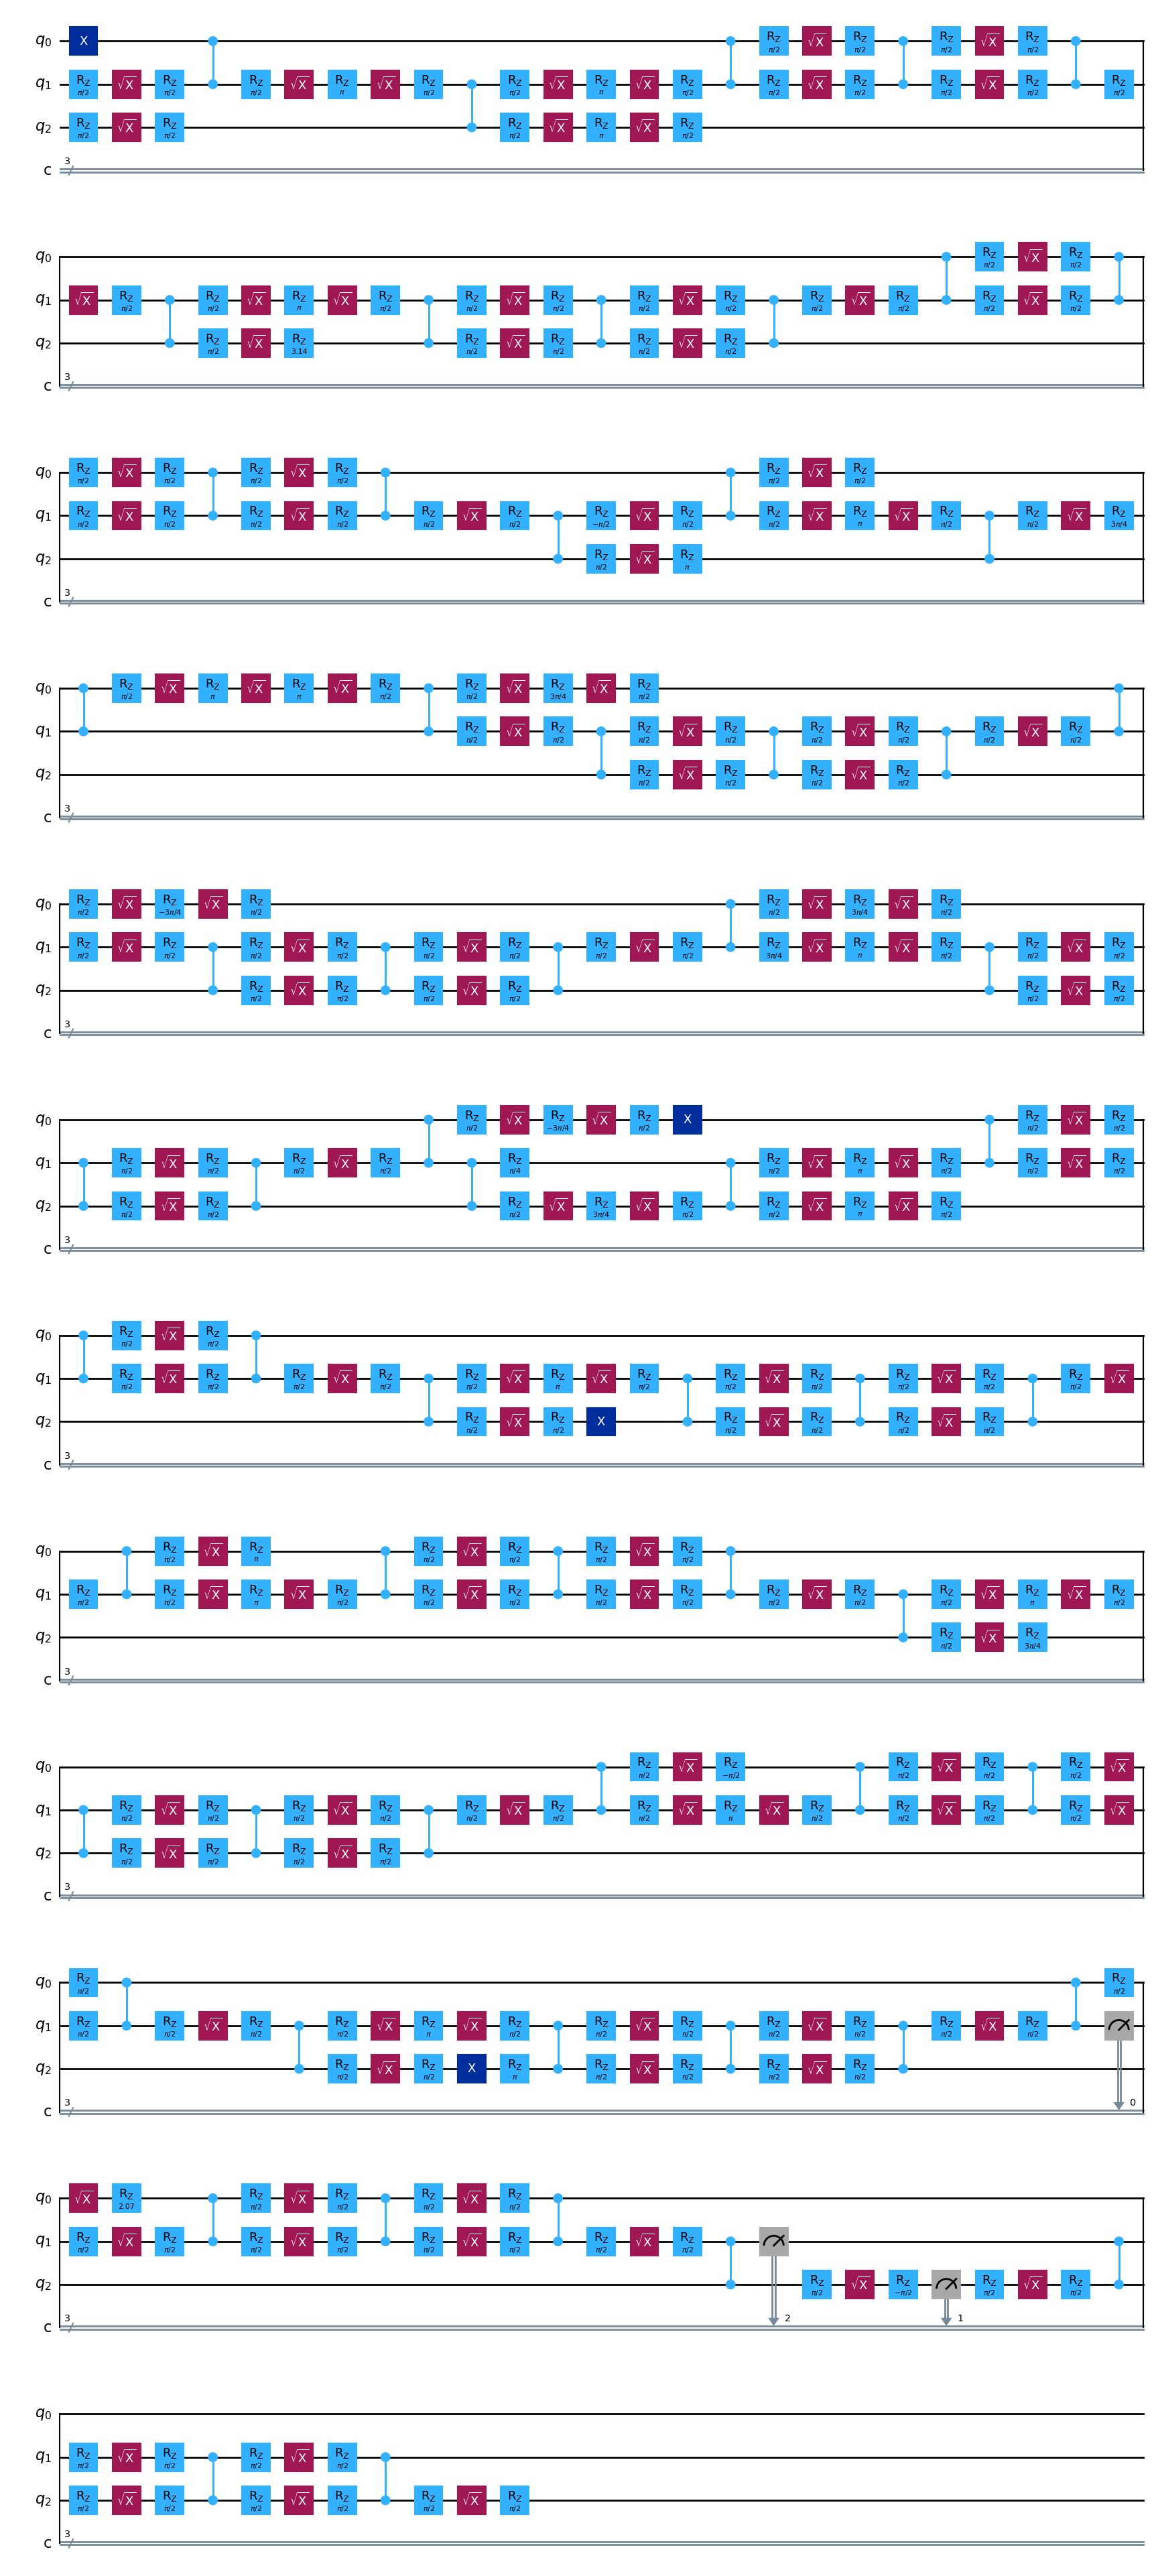

In [16]:
tqc, mapping = transpile_with_mapping(qc, backend)
tqc.draw("mpl")

In [17]:
sv1, sv2 = get_statevectors(qc, tqc)
sv1.draw("latex")

<IPython.core.display.Latex object>

In [18]:
sv2.draw("latex")

<IPython.core.display.Latex object>

In [19]:
fidelity = state_fidelity(sv1, sv2)
print("State fidelity:", fidelity)

State fidelity: 1.0000000000000249


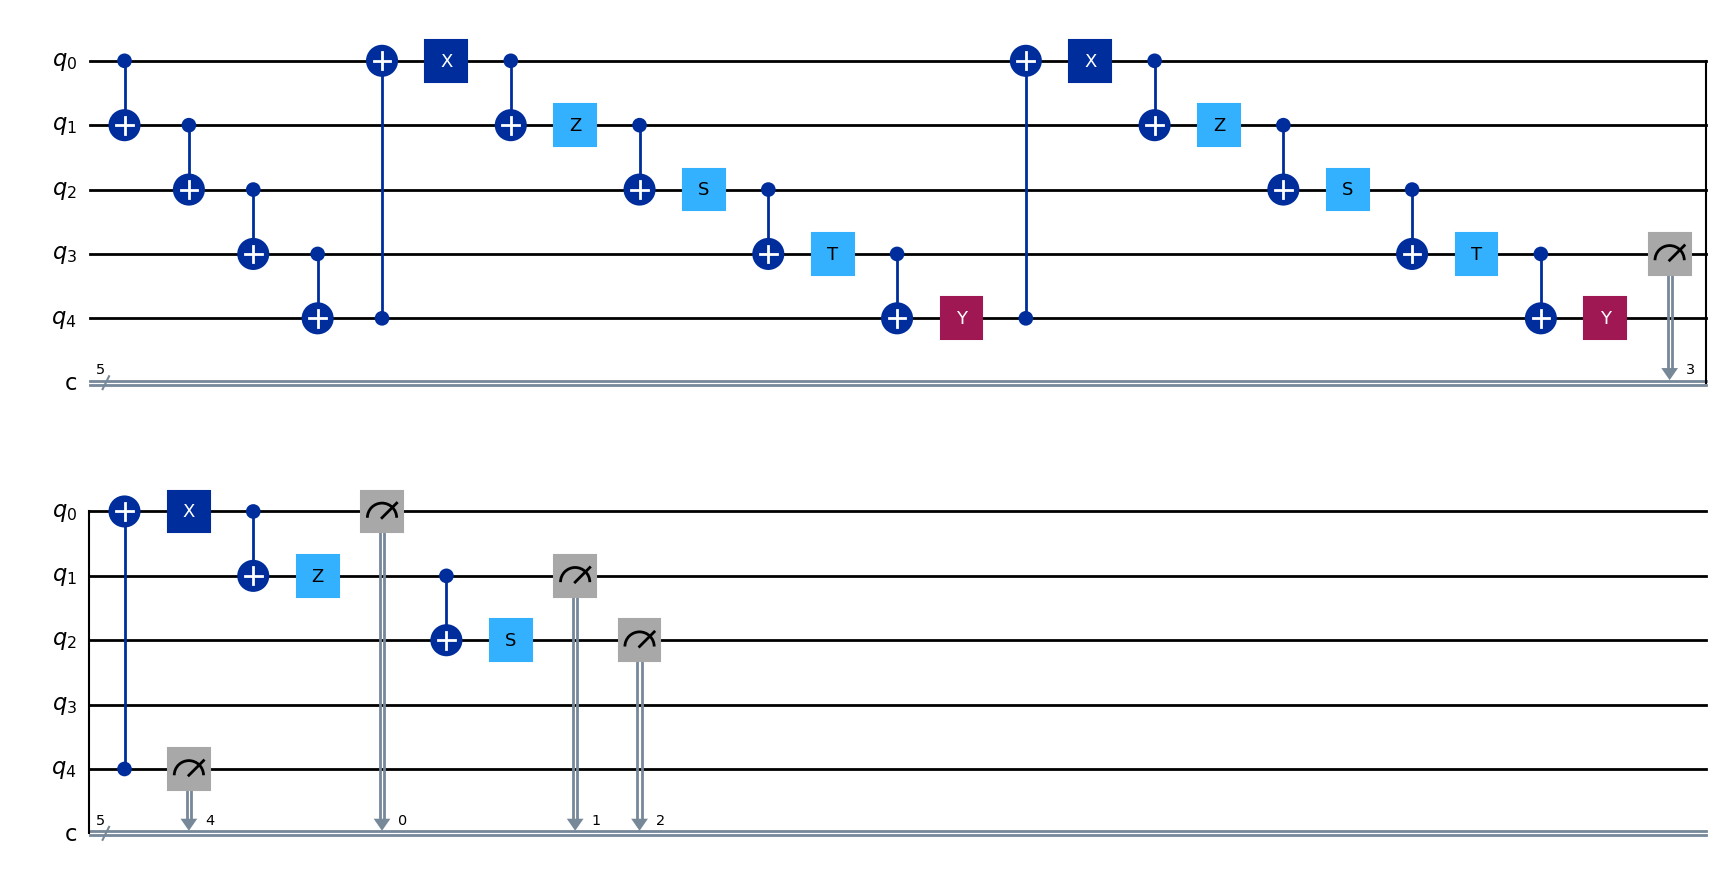

In [20]:
qc = QuantumCircuit(5, 5)
qc.cx(0, 1)
qc.cx(1, 2)
qc.cx(2, 3)
qc.cx(3, 4)
qc.cx(4, 0)
qc.x(0)
qc.cx(0, 1)
qc.z(1)
qc.cx(1, 2)
qc.s(2)
qc.cx(2, 3)
qc.t(3)
qc.cx(3, 4)
qc.y(4)
qc.cx(4, 0)
qc.x(0)
qc.cx(0, 1)
qc.z(1)
qc.cx(1, 2)
qc.s(2)
qc.cx(2, 3)
qc.t(3)
qc.cx(3, 4)
qc.y(4)
qc.cx(4, 0)
qc.x(0)
qc.cx(0, 1)
qc.z(1)
qc.cx(1, 2)
qc.s(2)
qc.measure([0, 1, 2, 3, 4], [0, 1, 2, 3, 4])
qc.draw("mpl")

In [21]:
tqc, mapping = transpile_with_mapping(qc, backend)
sv1, sv2 = get_statevectors(qc, tqc)
sv1.draw("latex")

[BasisTranslator] Warning: Found a built-in equivalence table that covers the provided custom_basis. Using 'heron'
Final mapping after swaps: {0: 0, 1: 1, 2: 2, 3: 3, 4: 4}
[BasisTranslator] Warning: Found a built-in equivalence table that covers the provided custom_basis. Using 'heron'


<IPython.core.display.Latex object>

In [22]:
sv2.draw("latex")

<IPython.core.display.Latex object>

In [23]:
fidelity = state_fidelity(sv1, sv2)
print("State fidelity:", fidelity)

State fidelity: 1.0000000000000218
